In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

In [8]:
# 데이터 수집 (가져오기)
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0])

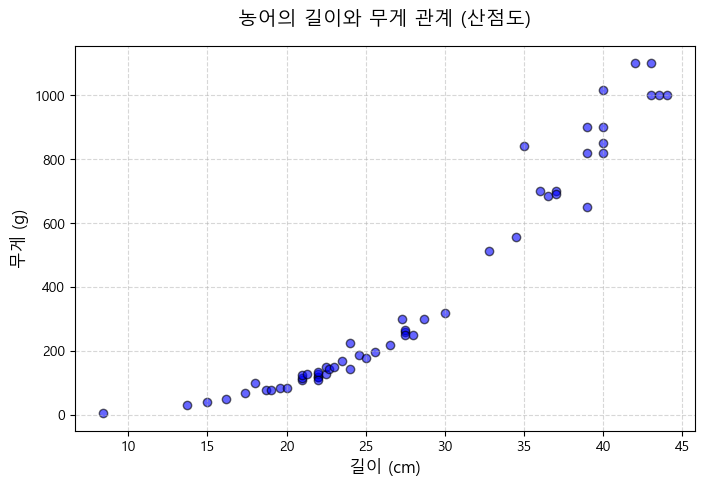

In [28]:
# 데이터 시각화 해보기
import matplotlib.pyplot as plt
# 한글 깨짐 방지 설정 (Windows/Mac 공용)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows용 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 기호 깨짐 방지

# 2. 산점도 그리기
plt.figure(figsize=(8, 5)) # 그래프 크기 설정
plt.scatter(perch_length, perch_weight, color='blue', alpha=0.6, edgecolors='black')

# 3. 그래프 꾸미기
plt.title('농어의 길이와 무게 관계 (산점도)', fontsize=14, pad=15)
plt.xlabel('길이 (cm)', fontsize=12)
plt.ylabel('무게 (g)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5) # 격자 추가

# 4. 출력
plt.show()

In [9]:
# 훈련 데이터 테스트 데이터 나누기
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)

In [12]:
# 데이터 전처리 
train_input = train_input.reshape(-1, 1) # 형태(구조)를 변경해준다. 1차원 -> 2차원 행렬로 
test_input = test_input.reshape(-1, 1)

In [18]:
model = KNeighborsRegressor()

In [19]:
# 학습! 사이킷런 모델은 X(Feature) 데이터로 2차원 배열을 입력받기 원함.
model.fit(train_input, train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [21]:
# 예측 
model.predict( [[29]] )

array([248.])

In [30]:
# 평가 : R^2 결정계수
model.score(test_input, test_target)

0.992809406101064

In [33]:
from sklearn.metrics import mean_absolute_error

test_prediction = model.predict(test_input) # 예측한 결과값
mae = mean_absolute_error(test_target, test_prediction) # MAE 지표를 계산
print(mae)   # 19.16

19.157142857142862


In [ ]:
# K 값의 변화에 따라서, 그래프를 그려보자.
# K의 값이 1, 5, 10일 때 각각의 차이

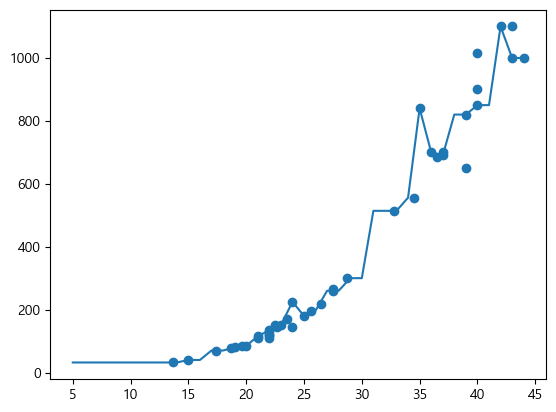

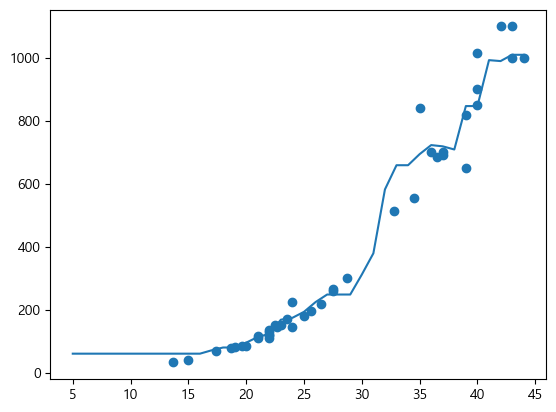

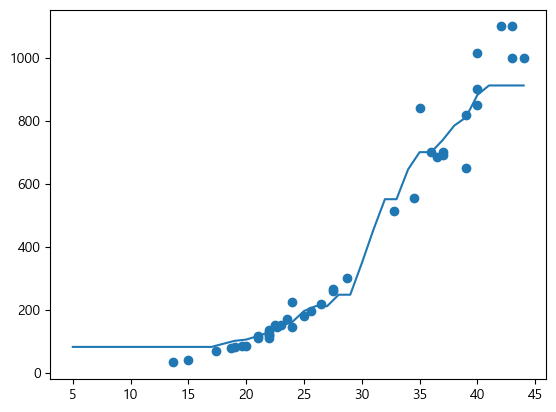

In [41]:
import matplotlib.pyplot as plt

model = KNeighborsRegressor()
x = np.arange(5, 45).reshape(-1, 1)
for n in [1, 5, 10]:
    model.n_neighbors = n
    model.fit(train_input, train_target)
    prediction = model.predict(x)
    plt.scatter(train_input, train_target)
    plt.plot(x, prediction)
    plt.show()

# 선형 회귀
---

In [49]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(train_input, train_target)

# 예측
print(model.predict([[100]]))
# 평가
model.score(test_input, test_target) # 결정계수 R^2

[3192.69585141]


0.824750312331356

In [54]:
# w 기울기
print("w :", model.coef_)
# b 절편
print("b :", model.intercept_)

w : [39.01714496]
b : -709.0186449535474


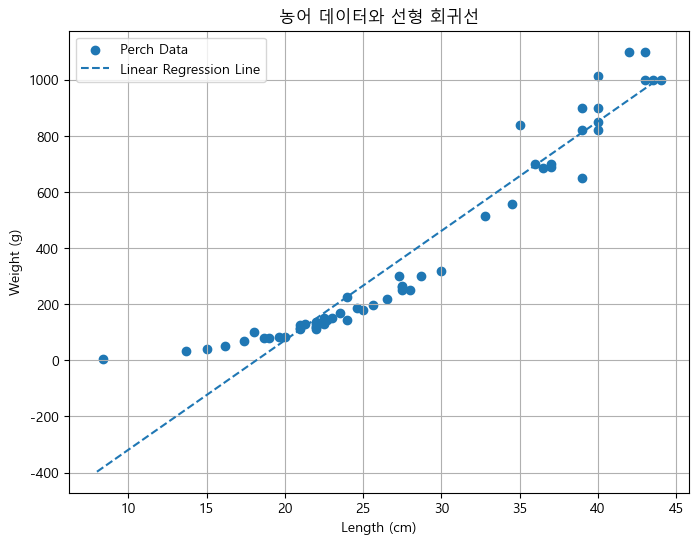

In [75]:
# sklearn은 2차원 입력 필요
perch_length = perch_length.reshape(-1, 1)

# 훈련/테스트 분할
train_input, test_input, train_target, test_target = train_test_split(
    perch_length,
    perch_weight,
    random_state=42
)

# 모델 생성
model = LinearRegression()

# 학습
model.fit(train_input, train_target)

# 예측
test_prediction = model.predict(test_input)

# 회귀선용 x
x = np.arange(8, 45).reshape(-1, 1)
prediction = model.predict(x)

# 그래프
plt.figure(figsize=(8, 6))

plt.scatter(perch_length, perch_weight, label='Perch Data')

plt.plot(x, prediction, '--', label='Linear Regression Line')

plt.xlabel('Length (cm)')
plt.ylabel('Weight (g)')
plt.title('농어 데이터와 선형 회귀선')

plt.legend()
plt.grid(True)

plt.show()

In [69]:
print(model.score(test_input, test_target)) # 테스트 데이터 평가 -> 0.82
print(model.score(train_input, train_target)) # 훈련 데이터 평가 -> 0.94

0.824750312331356
0.9398463339976041


In [62]:
# MSE : 평균 제곱 오차 -> 손실함수
from sklearn.metrics import mean_squared_error

mean_squared_error(test_target, test_prediction) # 721
# 손실함수를 최소화 시키는 것이 선형 회귀의 학습이다.

721.7385714285714

# 다항회귀

In [128]:
# 방법 1: 수동 (Ch03-2)
train_poly = np.column_stack((train_input**2, train_input))
print(train_poly[:2])

# 방법 2: PolynomialFeatures (Ch03-3, 오늘 오후)
# 전처리 도구 - Feature를 자동으로 생성해준다.
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(include_bias=False)  # 절편은 포함시키지 않음.
poly.fit(train_input)                          # train에만 fit
train_poly = poly.transform(train_input)
test_poly  = poly.transform(test_input)        # transform만

print(train_poly[:2])

[[384.16  19.6 ]
 [484.    22.  ]]
[[ 19.6  384.16]
 [ 22.   484.  ]]


In [129]:
model = LinearRegression()
model.fit(train_poly, train_target) # 학습
model.predict( [ [50**2, 50] ] ) # 예측 50cm 농어의 예측된 무게는? 1573

array([-53728.04563084])

In [127]:
# parameter 를 구해본다.
print(model.coef_)        # w 가중치 [ x^2, x] 계수 
print(model.intercept_)  # b : y 절편

[  1.01433211 -21.55792498]
116.0502107827827


### 2차 방정식
$1.01x^2 - 21.56x + 116$

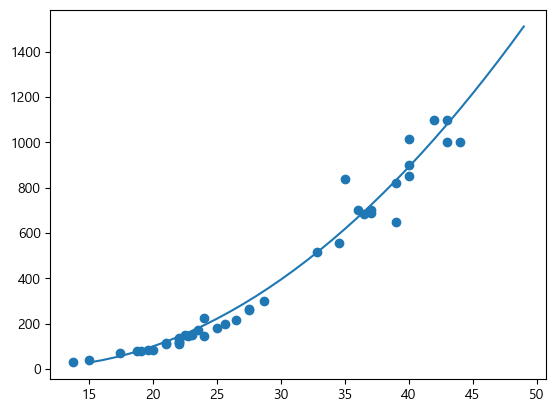

In [89]:
# 시각화
point = np.arange(15, 50) # 점의 범위 scale
plt.scatter(train_input, train_target)
plt.plot(point, 1.01 * point ** 2 - 21 * point + 116)
# plt.plot(point, model.coef_[0] * point ** 2 + model.coef_[1] * point + model.intercept_)
plt.show()

In [87]:
# 평가 
test_ploy = np.column_stack((test_input**2, test_input)) # 테스트 데이터 구조 변경 1D -> 2D
print(model.score(test_poly, test_target)) # 결정계수 R^2

0.9775935108325123


In [102]:
print(model.score(train_poly, train_target)) # 결정계수 R^2 훈련 데이터셋

0.9706807451768623
